# 🦜🔗 LangChain Crash Course (3–5 Hours)
### Using FREE Groq API | Complete Beginner to Intermediate

---

## Table of Contents
1. [Setup & Installation](#1-setup)
2. [LLMs & Chat Models with Groq](#2-llms)
3. [Prompt Templates](#3-prompts)
4. [LCEL — LangChain Expression Language (Chains)](#4-lcel)
5. [Output Parsers](#5-parsers)
6. [Memory & Conversation History](#6-memory)
7. [Document Loaders & Text Splitters](#7-docs)
8. [Embeddings & Vector Stores](#8-vectors)
9. [RAG — Retrieval Augmented Generation](#9-rag)
10. [Agents & Tools](#10-agents)

---
**Get your FREE Groq API key at:** https://console.groq.com


---
## 1. Setup & Installation
### What is LangChain?
LangChain is a framework for building applications powered by Large Language Models (LLMs).

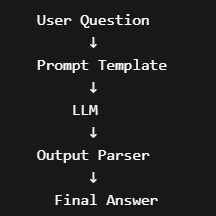

It provides:

- **Chains** — sequence LLM calls     
In LangChain, we connect things like this:-   
Prompt → LLM → Output    
This is called a chain.

- **Memory** — persist state across calls
Memory means remembering things.  
Like chat history.  

- **Agents** — let LLMs take actions with tools
They can take decisions.    
They can use tools.    
agent = brain + action

Example:

User asks:
What is 10 * 20?
- **RAG** — ground LLMs in your own data

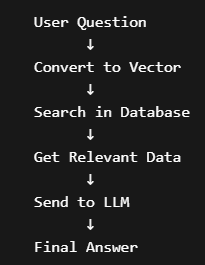

### Why Groq?
Groq provides **blazing fast inference** on LLaMA 3, Mixtral, and Gemma models — all **FREE** on the developer tier!

In [1]:
# Install all required packages
!pip install langchain langchain-groq langchain-community langchain-huggingface
!pip install faiss-cpu sentence-transformers pypdf python-dotenv
!pip install duckduckgo-search streamlit

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Nidhi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Nidhi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Nidhi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from dotenv import load_dotenv
import os

# 👇 IMPORTANT: yeh line change karo
load_dotenv(dotenv_path="./.env", override=True)

#print("KEY:", os.getenv("GROQ_API_KEY"))

True

---
## 2. LLMs & Chat Models with Groq

### Key Groq Models (all free):
| Model | Context | Best For |
|-------|---------|----------|
| `llama3-8b-8192` | 8k | Fast, general tasks |
| `llama3-70b-8192` | 8k | Complex reasoning |
| `mixtral-8x7b-32768` | 32k | Long documents |
| `gemma2-9b-it` | 8k | Instruction following |

### Two Ways to Use LLMs in LangChain:
1. **`ChatGroq`** — Chat models (recommended, uses messages)
2. **`Groq`** — Text completion (older style)

In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7,      # 0 = deterministic, 1 = creative
    max_tokens=1024,
)

print(f"Model: {llm.model_name}")

C:\Users\Nidhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: llama-3.1-8b-instant


In [4]:
# Basic invocation — simplest way to call an LLM
response = llm.invoke("What is LangChain in one sentence?")

print(type(response))       # AIMessage object
print(response.content)     # The actual text
print(response.usage_metadata)  # Token usage


<class 'langchain_core.messages.ai.AIMessage'>
LangChain is an open-source Python library that enables developers to build large language models (LLMs) into scalable, production-ready applications through a modular architecture and a simple, Pythonic API.
{'input_tokens': 43, 'output_tokens': 39, 'total_tokens': 82}


In [5]:
# Using Messages directly — how Chat Models work internally

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

messages = [
    SystemMessage(content="You are a helpful Python tutor. Be concise."),
    HumanMessage(content="What is a list comprehension?"),
]


response = llm.invoke(messages)
print(response.content)

**List Comprehension in Python**

A list comprehension is a concise way to create a new list from an existing list or other iterable by applying a transformation to each element. It's a powerful feature that replaces the need for explicit loops.

**Basic Syntax**

```python
new_list = [expression for element in iterable]
```

**Example**

Create a new list with squares of numbers from 1 to 5:
```python
numbers = [1, 2, 3, 4, 5]
squares = [x**2 for x in numbers]
print(squares)  # [1, 4, 9, 16, 25]
```

**Extended Syntax**

Add conditions to filter elements:
```python
numbers = [1, 2, 3, 4, 5]
even_squares = [x**2 for x in numbers if x % 2 == 0]
print(even_squares)  # [4, 16]
```

**Use Cases**

1. **Data transformation**: Create a new list with transformed data.
2. **Data filtering**: Create a new list with elements that meet certain conditions.
3. **Data aggregation**: Create a new list with aggregated values.

List comprehensions are a concise and readable way to perform common operat

In [6]:
# Streaming — get tokens as they're generated

print("Streaming response:")
print("-" * 40)
for chunk in llm.stream("Tell me 3 facts about Python programming."):
    print(chunk.content, end="", flush=True)
print()  # newline at end

Streaming response:
----------------------------------------
Here are three facts about Python programming:

1. **Easy to Learn**: Python is known for its simplicity and readability, making it a great language for beginners. Its syntax is designed to be easy to understand and use, which is why it's often taught in introductory programming courses.

2. **Versatile**: Python can be used for a wide range of applications, including web development, data analysis, machine learning, automation, and more. Its versatility is due to its extensive libraries and frameworks, which make it easy to adapt to different use cases.

3. **Large Community**: Python has a massive and active community of developers, which contributes to its popularity and growth. This community creates and maintains many libraries, frameworks, and tools that make Python an even more powerful language. Additionally, the community provides extensive documentation, tutorials, and support resources for Python developers.


In [7]:
# Batch — run multiple prompts at once (efficient!)
prompts = [
    "What is Python?",
    "What is JavaScript?",
    "What is Rust?",
]

responses = llm.batch(prompts)
for prompt, resp in zip(prompts, responses):
    print(f"Q: {prompt}")
    print(f"A: {resp.content[:100]}...")
    print()

Q: What is Python?
A: **What is Python?**

Python is a high-level, interpreted programming language ...

Q: What is JavaScript?
A: **JavaScript: A High-Level, Dynamic Programming Language**

JavaScript is a high-level, dynamic prog...

Q: What is Rust?
A: Rust is a systems programming language that runs on a variety of platforms, including Linux, Windows...



---
## 3. Prompt Templates

Prompt Templates allow you to create **reusable, dynamic prompts** with variables.

### Types:
- `PromptTemplate` — for simple string prompts
- `ChatPromptTemplate` — for chat-style prompts (most common)
- `FewShotPromptTemplate` — includes examples to guide the LLM

In [8]:
from langchain_core.prompts import PromptTemplate

# Basic PromptTemplate — use {variable} placeholders
template = PromptTemplate(
    input_variables=["topic", "level"],
    template="Explain {topic} to a {level} in 3 bullet points."
)


# Format the prompt
formatted = template.format(topic="neural networks", level="10-year-old")
print(formatted)
print()

# Invoke the LLM with the formatted prompt
response = llm.invoke(formatted)
print(response.content)

Explain neural networks to a 10-year-old in 3 bullet points.

Imagine you have a super smart robot friend that can learn and get better at tasks. This is kind of like how a neural network works. Here are 3 simple points to explain it to you:

* **Lots of connections**: A neural network is made up of many tiny computers (called "neurons") that are connected to each other like a big web. Each neuron can talk to many of its friends, and they all work together to help the robot learn.
* **Learning from examples**: When the robot is shown many examples of something (like pictures of dogs and cats), it uses those connections to figure out what makes a dog a dog and what makes a cat a cat. It's kind of like how you learn to recognize different animals by looking at many pictures.
* **Getting better and better**: The more examples the robot sees, the better it gets at recognizing things. It's like how you get better at reading or riding a bike the more you practice. The robot is constantly lea

In [9]:

# chatprompttemp

from langchain_core.prompts import ChatPromptTemplate

# ChatPromptTemplate — the modern, recommended approach
chat_template = ChatPromptTemplate.from_messages([
    ("system", "You are an expert {domain} teacher. Always be encouraging."),
    ("human", "Explain {concept} in simple terms."),
])


# Format returns a list of messages
messages = chat_template.format_messages(
    domain="machine learning",
    concept="gradient descent"
)

for msg in messages:
    print(f"{type(msg).__name__}: {msg.content}")
    print()

SystemMessage: You are an expert machine learning teacher. Always be encouraging.

HumanMessage: Explain gradient descent in simple terms.



In [10]:
# Invoke LLM with a ChatPromptTemplate
response = llm.invoke(messages)
print(response.content)


You're about to learn one of the most powerful concepts in machine learning: Gradient Descent!

**What is Gradient Descent?**

Imagine you're on a mountain, and you want to get to the bottom. You don't know the shortest path, but you know which direction is downhill. That's basically what gradient descent is.

**How Gradient Descent Works**

1. **Start at the top**: You begin at a random point on the mountain (the top).
2. **Measure the slope**: You measure the slope of the mountain at your current point. This slope tells you the direction of the steepest descent.
3. **Take a step**: You take a small step in the direction of the steepest descent.
4. **Repeat**: You repeat steps 2 and 3 until you're at the bottom of the mountain.

**How Gradient Descent is Applied to Machine Learning**

In machine learning, gradient descent is used to minimize the error between your model's predictions and the actual data. Here's how:

1. **Start with a model**: You begin with a random model (like a lin

In [11]:
# fewshot prompt

from langchain_core.prompts import FewShotPromptTemplate

# FewShotPromptTemplate — teach the model with examples
examples = [
    {"word": "happy", "antonym": "sad"},
    {"word": "tall",  "antonym": "short"},
    {"word": "fast",  "antonym": "slow"},
]

example_template = PromptTemplate(
    input_variables=["word", "antonym"],
    template="Word: {word}\nAntonym: {antonym}"
)

few_shot = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_template,
    prefix="Give the antonym of each word:",
    suffix="Word: {input}\nAntonym:",
    input_variables=["input"]
)


formatted = few_shot.format(input="bright")

print(formatted)
print()
print("LLM Response:", llm.invoke(formatted).content)



Give the antonym of each word:

Word: happy
Antonym: sad

Word: tall
Antonym: short

Word: fast
Antonym: slow

Word: bright
Antonym:

LLM Response: The antonym of the word "bright" is "dark".


In [12]:
# MessagesPlaceholder — dynamic injection of conversation history
from langchain_core.prompts import MessagesPlaceholder

chat_with_history = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    MessagesPlaceholder(variable_name="history"),  # inject history here
    ("human", "{input}"),
])


# Simulate a conversation history
history = [
    HumanMessage(content="My name is Nidhi."),
    AIMessage(content="Nice to meet you, Nidhi!"),
]
messages = chat_with_history.format_messages(history=history, input="What is my name?")

response = llm.invoke(messages)
print(response.content)  # Should remember 'Nidhi'


Your name is Nidhi.


---
## 4. LCEL — LangChain Expression Language (Chains)

LCEL is the **modern way** to compose LangChain components using the pipe `|` operator.

```
chain = prompt | llm | output_parser
```

Benefits of LCEL:
- Built-in streaming, batching, async
- Easy to compose and modify
- Type-safe with clear data flow
- Replaces old `LLMChain`, `SequentialChain`

In [13]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# The simplest LCEL chain: prompt | llm | parser
prompt = ChatPromptTemplate.from_messages([
    ("human", "Tell me a {adjective} joke about {topic}.")
])

parser = StrOutputParser()  # converts AIMessage -> plain string

chain = prompt | llm | parser


# Invoke with a dict of inputs
result = chain.invoke({"adjective": "funny", "topic": "Python"})
print(result)
print(type(result))  # str, not AIMessage


Why did the Python go to therapy?

Because it was feeling a little "sliced" under the pressure.
<class 'langchain_core.messages.base.TextAccessor'>


In [14]:
print("Streaming joke:")

for chunk in chain.stream({
    "adjective" : "terrible",
    "topic": "AI"}):
    print(chunk, end = "", flush = True)

print()    

Streaming joke:
Why did the AI program go to therapy?

Because it was struggling to process its emotions.


In [15]:

# Batch with LCEL — run many inputs at once
inputs = [
    {"adjective": "dad", "topic": "cats"},
    {"adjective": "nerdy", "topic": "databases"},
    {"adjective": "quick", "topic": "cloud computing"},
]

results = chain.batch(inputs)

for i, r in enumerate(results, 1):
    print(f"Joke {i}: {r[:80]}...")
    print()



Joke 1: Why did the cat join a band? Because it wanted to be the purr-cussionist....

Joke 2: Why did the database schema go to therapy?

Because it was feeling a little "unn...

Joke 3: Why did the cloud go to therapy? 

Because it was feeling a little "foggy" about...



In [16]:
# Sequential Chains — chain outputs become next chain's inputs
from langchain_core.runnables import RunnablePassthrough

# Chain 1: Generate a topic
topic_prompt = ChatPromptTemplate.from_messages([
    ("human", "Give me one interesting topic in {field}. Reply with just the topic name.")
])

topic_chain = topic_prompt | llm | StrOutputParser()

# Chain 2: Write about that topic
essay_prompt = ChatPromptTemplate.from_messages([
    ("human", "Write 3 sentences about: {topic}")
])


essay_chain = essay_prompt | llm | StrOutputParser()


# Combine: output of topic_chain feeds into essay_chain
full_chain = topic_chain | (lambda topic: {"topic": topic}) | essay_chain

result = full_chain.invoke({"field": "quantum computing"})
print(result)



Quantum Supremacy refers to the hypothetical ability of a quantum computer to solve a specific problem that is beyond the capabilities of a classical computer, demonstrating its superiority in certain computational tasks. The Google AI Lab achieved this milestone in 2019 with the publication of a paper titled "Quantum supremacy using a programmable superconducting quantum processor," where they successfully performed a complex calculation that no classical computer could match. This achievement marks a significant step towards the development of practical applications for quantum computing and has sparked further research and innovation in the field.


In [17]:

# RunnableParallel — run multiple chains at the same time
from langchain_core.runnables import RunnableParallel

pros_prompt = ChatPromptTemplate.from_messages([
    ("human", "List 3 pros of {technology} in bullet points.")
])
cons_prompt = ChatPromptTemplate.from_messages([
    ("human", "List 3 cons of {technology} in bullet points.")
])

pros_chain = pros_prompt | llm | StrOutputParser()
cons_chain = cons_prompt | llm | StrOutputParser()

parallel_chain = RunnableParallel(
    pros=pros_chain,
    cons=cons_chain,
)

result = parallel_chain.invoke({"technology": "Python"})

print("PROS:")
print(result["pros"])
print("\nCONS:")
print(result["cons"])

PROS:
Here are three pros of Python:

* **Easy to Learn and Use**: Python has a simple syntax and is relatively easy to learn, making it a great language for beginners and experienced programmers alike. Its syntax is clean and straightforward, allowing developers to focus on problem-solving rather than getting bogged down in complex code.
* **Versatile and Adaptable**: Python can be used for a wide range of applications, including web development, data analysis, machine learning, automation, and more. Its flexibility makes it a popular choice for many industries and use cases.
* **Large and Active Community**: Python has a massive and active community of developers, which means there are many resources available for learning and troubleshooting. This community also contributes to a wide range of libraries and frameworks that make it easy to get started with various tasks and projects.

CONS:
Here are three potential cons of Python:

* **Slow performance for CPU-intensive tasks**: Pytho

In [18]:
# RunnablePassthrough — pass input through unchanged
from langchain_core.runnables import RunnablePassthrough

# Useful when you want to preserve the original input alongside chain output
chain_with_input = RunnableParallel(
    original=RunnablePassthrough(),
    response=ChatPromptTemplate.from_messages([
        ("human", "Translate '{text}' to French.")
    ]) | llm | StrOutputParser()
)

result = chain_with_input.invoke({"text": "Hello, how are you?"})
print("Original:", result["original"])
print("French:", result["response"])

Original: {'text': 'Hello, how are you?'}
French: The translation of "Hello, how are you?" to French is:

"Bonjour, comment ça va?"

Alternatively, you can also use:

- "Salut, comment ça va?" (more informal)
- "Bonjour, comment allez-vous?" (more formal)
- "Bonjour, comment vas-tu?" (even more informal)


---
## 5. Output Parsers

Output parsers transform the LLM's raw text output into structured Python objects.

| Parser | Output Type | Use Case |
|--------|-------------|----------|
| `StrOutputParser` | `str` | Plain text |
| `JsonOutputParser` | `dict` | JSON data |
| `PydanticOutputParser` | `BaseModel` | Validated objects |
| `CommaSeparatedListOutputParser` | `list` | Simple lists |

In [19]:
from langchain_core.output_parsers import JsonOutputParser

# JSON Output Parser — get structured data back
json_prompt = ChatPromptTemplate.from_messages([
    ("system", "Always respond with valid JSON."),
    ("human", "Give me info about {person} as JSON with keys: name, field, achievement.")
])

# LCEL CHAIN

json_chain = json_prompt | llm | JsonOutputParser()

result = json_chain.invoke({"person": "Alan Turing"})


print(type(result))  # dict!
print(result)
print(result["name"])  # Access like a normal dict


<class 'dict'>
{'name': 'Alan Mathison Turing', 'field': 'Computer Science, Mathematics, Logic, and Cryptography', 'achievement': 'Developed the theoretical foundations of modern computer science, including the concept of the universal Turing machine, made significant contributions to codebreaking during World War II, and proposed the Turing Test for measuring intelligence.'}
Alan Mathison Turing


In [20]:
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing import List

# Define what you want the output to look like
class MovieReview(BaseModel):
    title: str = Field(description="Movie title")
    rating: float = Field(description="Rating from 0 to 10")
    pros: List[str] = Field(description="List of pros")
    cons: List[str] = Field(description="List of cons")
    summary: str = Field(description="One sentence summary")

parser = PydanticOutputParser(pydantic_object=MovieReview)

# Get format instructions to include in the prompt
print(parser.get_format_instructions()[:300])

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]}


In [21]:
movie_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a movie critic. {format_instructions}"),
    ("human", "Review the movie: {movie}")
])

movie_chain = movie_prompt | llm | parser


review = movie_chain.invoke({
    "movie": "Inception",
    "format_instructions": parser.get_format_instructions()
})

print(type(review))  
print(f"Title: {review.title}")
print(f"Rating: {review.rating}/10")
print(f"Pros: {review.pros}")
print(f"Cons: {review.cons}")
print(f"Summary: {review.summary}")



<class '__main__.MovieReview'>
Title: Inception
Rating: 9.5/10
Pros: ['Original and complex storyline', 'Impressive action sequences', 'Strong performances from the cast', 'Cinematography and visual effects are breathtaking', 'Themes of reality and dreams are thought-provoking']
Cons: ['Pacing can be slow at times', 'Some viewers may find the storyline confusing']
Summary: Inception is a mind-bending sci-fi action film that delves into the world of dream-sharing, where a team of thieves must plant an idea in someone's mind instead of stealing one. With its complex storyline, impressive action sequences, and strong performances from the cast, Inception is a must-see film for fans of the genre.


In [22]:
from langchain_core.output_parsers import CommaSeparatedListOutputParser

list_parser = CommaSeparatedListOutputParser()
# convert commas seprate text into python

list_prompt = ChatPromptTemplate.from_messages([
    ("human", "List 5 {category}. {format_instructions}")
])

list_chain = list_prompt | llm | list_parser

result = list_chain.invoke({
    "category": "popular Python libraries",
    "format_instructions": list_parser.get_format_instructions()
})

print(type(result))  # list!
for i, item in enumerate(result, 1):
    print(f"{i}. {item.strip()}")

<class 'list'>
1. numpy
2. pandas
3. matplotlib
4. scikit-learn
5. requests


---
## 6. Memory & Conversation History

Memory allows your chatbot to **remember previous messages**.

### Modern LangChain Memory Approaches:
1. **Manual history** — store messages in a Python list (simplest)
2. **`ChatMessageHistory`** — LangChain's message store
3. **`RunnableWithMessageHistory`** — automatic history management
4. **Summary Memory** — summarize old messages to save tokens

In [23]:
# Approach 1: Manual history (simplest, most transparent)
from langchain_core.messages import HumanMessage, AIMessage


chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Remember the conversation."),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{input}")
])

chain = chat_prompt | llm | StrOutputParser()

# Store conversation
history = []

def chat(user_input):
    response = chain.invoke({"input": user_input, "history": history})
    history.append(HumanMessage(content=user_input))
    history.append(AIMessage(content=response))
    return response
# Simulate a conversation
print("You:", "Hi, my name is Nidhi and I love Python.")
print("Bot:", chat("Hi, my name is Nidhi and I love Python."))
print()   
print("You:", "What programming language do I love?")
print("Bot:", chat("What programming language do I love?"))
print() 
print("You:", "What is my name?")
print("Bot:", chat("What is my name?"))

You: Hi, my name is Nidhi and I love Python.
Bot: Hello Nidhi.  It's great to hear that you love Python. Python is a popular and versatile programming language that can be used for a wide range of applications, from web development to data analysis and artificial intelligence. What do you enjoy most about Python, or what are you currently working on?

You: What programming language do I love?
Bot: You love Python.

You: What is my name?
Bot: Your name is Nidhi.


In [24]:
# Approach 2: RunnableWithMessageHistory — production-ready memory
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

# Store for different sessions (like different users)
store = {}  # {session_id: ChatMessageHistory}

def get_session_history(session_id: str) -> ChatMessageHistory:
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{input}")
])

base_chain = prompt | llm | StrOutputParser()

# Wrap with message history management
# add atomatic memory
chain_with_history = RunnableWithMessageHistory(
    base_chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="history",
)

# Use session_id to track different conversations
config_user1 = {"configurable": {"session_id": "user_alice"}}
config_user2 = {"configurable": {"session_id": "user_bob"}}

# Alice's conversation
r1 = chain_with_history.invoke({"input": "I'm Alice, I like cats."}, config=config_user1)
print("Alice 1:", r1)



# Bob's conversation
r2 = chain_with_history.invoke({"input": "I'm Bob, I like dogs."}, config=config_user2)
print("Bob 1:", r2)


# Alice asks again — should remember she likes cats
r3 = chain_with_history.invoke({"input": "What pet do I like?"}, config=config_user1)
print("Alice 2:", r3)


# Bob asks — should remember he likes dogs
r4 = chain_with_history.invoke({"input": "What pet do I like?"}, config=config_user2)
print("Bob 2:", r4)



Alice 1: Hello Alice, nice to meet you. Cats are wonderful pets, aren't they? They're so affectionate and independent at the same time. Do you have a cat at home, or are you thinking of getting one?
Bob 1: Hi Bob, it's nice to meet you. Dogs are wonderful companions, aren't they? What kind of dogs do you like, or do you have a favorite breed?
Alice 2: You like cats.
Bob 2: You like dogs.


In [25]:
# Approach 3: Window Memory — only keep last N messages
from langchain_core.chat_history import InMemoryChatMessageHistory

WINDOW_SIZE = 4  
# keep last 4 messages (2 exchanges)
# 2 = user msg
# 2 ai msg

history_windowed = []
# store all msg

def chat_windowed(user_input):
    # Only pass last WINDOW_SIZE messages
    recent = history_windowed[-WINDOW_SIZE:]
    
    response = chain.invoke({"input": user_input, "history": recent})

    
    history_windowed.append(HumanMessage(content=user_input))
    history_windowed.append(AIMessage(content=response))
    return response

print("Window Memory Demo:")
chat_windowed("My favorite color is blue.")
chat_windowed("I live in Mumbai.")
chat_windowed("I work as a data scientist.")

# After window slides, might forget favorite color
result = chat_windowed("What is my favorite color?")
print(result)  # May or may not remember — depends on window

print(f"Total messages stored: {len(history_windowed)}")
print(f"Messages used in last call: {WINDOW_SIZE}")

Window Memory Demo:
You mentioned earlier that you "love the color blue" when I mentioned visiting the beaches in Mumbai. So, I'm assuming that blue is your favorite color. Am I correct?
Total messages stored: 8
Messages used in last call: 4


---
## 7. Document Loaders & Text Splitters

Before we can do RAG, we need to:
1. **Load** documents from various sources
2. **Split** them into smaller chunks

Step 1: Load document
→ PDF, text file, website

Step 2: Split document
→ break into small chunks

Step 3: Store chunks
→ later used in search

### Why split? 
LLMs have limited context windows. We split docs into small chunks, store them, and retrieve only the relevant chunks at query time.

Load → Split → Store → Retrieve

#### Document Loader — 
We convert file into Document object  , LangChain works with Document format  , Loader converts raw file → structured document
#### Core Understanding
File → Loader → Document → Ready for splitting
#### One-Line Summary
TextLoader loads file into LangChain Document format

In [26]:
from langchain_community.document_loaders import TextLoader

# Create a sample text file to load
sample_text = """LangChain is a framework for developing applications powered by large language models.

It enables applications that:
- Are context-aware: connect a language model to sources of context
- Can reason: rely on a language model to reason about what actions to take

The main components of LangChain are:
1. Models: LLMs and Chat Models
2. Prompts: Prompt Templates and Example Selectors
3. Chains: Sequences of calls to LLMs or other utilities
4. Memory: Persist application state between runs
5. Agents: Let LLMs take actions using tools
6. Retrievers: Interface for fetching relevant documents

LangChain was created by Harrison Chase and released in October 2022.
It quickly became one of the most popular open-source projects.
"""

# Write sample file
with open("sample_doc.txt", "w") as f:
    f.write(sample_text)

# Load the document
loader = TextLoader("sample_doc.txt", encoding="utf-8")
docs = loader.load()

print(f"Loaded {len(docs)} document(s)")
print(f"Document type: {type(docs[0])}")
print(f"Content preview: {docs[0].page_content[:100]}...")
print(f"Metadata: {docs[0].metadata}")

Loaded 1 document(s)
Document type: <class 'langchain_core.documents.base.Document'>
Content preview: LangChain is a framework for developing applications powered by large language models.

It enables a...
Metadata: {'source': 'sample_doc.txt'}


#### 📄 PDF Loader Notes
- PDF is broken into pages
- Each page becomes one document
#### Best Analogy
- Like a book  
- Each page is treated separately
#### Important Concept
- 1 PDF → many Documents  
- Each page = 1 Document  
#### Why This Is Important
- Later we split each page into smaller chunks  
- Then we store and search efficiently  
#### One-Line Summary  
- PDF → Pages → Documents



In [27]:
from langchain_community.document_loaders import PyPDFLoader

# PDF Loader — load and split PDF pages automatically
# (Uncomment and use your own PDF file)
# loader = PyPDFLoader("your_document.pdf")
# pages = loader.load()  # Each page is a Document
# print(f"Loaded {len(pages)} pages")
# print(pages[0].page_content[:200])

print("PyPDFLoader: Use PyPDFLoader('path/to/file.pdf') to load PDF files")
print("Each page becomes a separate Document object")

PyPDFLoader: Use PyPDFLoader('path/to/file.pdf') to load PDF files
Each page becomes a separate Document object


#### 🌐 Web Loader Notes (LangChain)

#### 📌 Simple Explanation
We load data directly from a website.  
Then convert it into document format.


#### 🧠 Core Idea
Website → HTML → Clean Text → Document  


#### ✂️ Why Splitting is Needed
We break big document into small parts.  


#### 🔥 Best Analogy
Like copy-paste from a website,  
but done automatically by code.


#### ⚙️ Why `bs4` is Used
Website has a lot of noise (ads, menus, buttons).  
We extract only useful content.


#### ⚠️ Common Issue
If internet is not working → it will fail.  

That’s why we use `try-except`.


#### 🎯 One-Line Summary
Load website → clean content → convert to document  


#### 🎤 Transition
Now we will split this document into small chunks.

In [35]:
import os
import bs4
os.environ["USER_AGENT"] = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
# set a user agent so website dont treat your script like sady bot

from langchain_community.document_loaders import WebBaseLoader

# Wikipedia — reliable, clean HTML, always works
loader = WebBaseLoader(
    web_paths=["https://en.wikipedia.org/wiki/Large_language_model"],
    bs_kwargs={
        "parse_only": bs4.SoupStrainer(id="mw-content-text")
        # only extract the main content section of the wikipedia page
        # this avoid navigation bars, side panel footer etc
    }
)

docs = loader.load()

print(f"Loaded {len(docs)} doc(s)")
print(docs[0].page_content[:500])


Loaded 1 doc(s)

Type of machine learning model
"LLM" redirects here. For other uses, see LLM (disambiguation).
Part of a series onMachine learningand data mining
Paradigms
Supervised learning
Unsupervised learning
Semi-supervised learning
Self-supervised learning
Reinforcement learning
Meta-learning
Online learning
Batch learning
Curriculum learning
Rule-based learning
Neuro-symbolic AI
Neuromorphic engineering
Quantum machine learning

Problems
Classification
Generative modeling
Regression
Clustering
Dimensio


#### 📄 Text Splitting (LangChain Notes)

#### 📌 Basic Idea
We break big document into small parts.  
These parts are called **chunks**.



#### 🧠 Core Concept
Big document → small chunks → better understanding


#### ⚠️ Chunk Overlap (Very Important)
We repeat some part between chunks.  

So AI does not lose context.


#### 📊 Visual Understanding
```
Chunk 1: [AAAA BBBB CCCC]  
Chunk 2:       [CCCC DDDD EEEE]  
Chunk 3:             [EEEE FFFF GGGG]
```

#### ⚙️ Why Recursive Splitter is Best
It tries smart splitting:

- First paragraph  
- Then sentence  
- Then word  


#### 🎯 One-Line Summary
Split documents into small chunks for better AI processing



```
🔹 RecursiveCharacterTextSplitter
Uses multiple rules
Tries:
paragraph
line
sentence
word
Keeps text more natural
Adds overlap → better understanding
Basically:

“Let me try to split this nicely like a human would.
```

In [36]:
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter
)

# RecursiveCharacterTextSplitter — BEST for most use cases
# Tries to split on paragraphs -> sentences -> words -> characters
splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,       # max characters per chunk
    chunk_overlap=30,     # overlap between chunks (for context)
    separators=["\n\n", "\n", ". ", " ", ""]  # try these in order

    # Order matters:
    # 1. Try splitting by paragraphs
    # 2. Then by line breaks
    # 3. Then by sentences
    # 4. Then by words
    # 5. Finally, brute-force split characters if nothing else works
)

chunks = splitter.split_documents(docs)
print(f"Original docs: {len(docs)}")
print(f"After splitting: {len(chunks)} chunks")
print()
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i+1} ({len(chunk.page_content)} chars) ---")
    # show chunk num and its len
    print(chunk.page_content)
    print()

Original docs: 1
After splitting: 808 chunks

--- Chunk 1 (197 chars) ---
Type of machine learning model
"LLM" redirects here. For other uses, see LLM (disambiguation).
Part of a series onMachine learningand data mining
Paradigms
Supervised learning
Unsupervised learning

--- Chunk 2 (197 chars) ---
Unsupervised learning
Semi-supervised learning
Self-supervised learning
Reinforcement learning
Meta-learning
Online learning
Batch learning
Curriculum learning
Rule-based learning
Neuro-symbolic AI

--- Chunk 3 (67 chars) ---
Neuro-symbolic AI
Neuromorphic engineering
Quantum machine learning

--- Chunk 4 (184 chars) ---
Problems
Classification
Generative modeling
Regression
Clustering
Dimensionality reduction
Density estimation
Anomaly detection
Data cleaning
AutoML
Association rules
Semantic analysis

--- Chunk 5 (149 chars) ---
Semantic analysis
Structured prediction
Feature engineering
Feature learning
Learning to rank
Grammar induction
Ontology learning
Multimodal learning

--- Chunk 6

```
CharacterTextSplitter
Uses only one rule (\n)
If newline is missing → bad splits
Can break sentences randomly
No overlap → context lost

Basically:

“Cut here. I don’t care what the sentence says.”
```

In [37]:
import logging
logging.getLogger("langchain_text_splitters").setLevel(logging.ERROR)

# CharacterTextSplitter — splits on a specific character
char_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=100,
    chunk_overlap=0
)

char_chunks = char_splitter.split_documents(docs)
print(f"CharacterTextSplitter produced {len(char_chunks)} chunks")

# Inspect overlap with RecursiveCharacterTextSplitter
print("\nChunk 0:", chunks[0].page_content[-50:])
print("Chunk 1 start:", chunks[1].page_content[:50])


CharacterTextSplitter produced 502 chunks

Chunk 0: aradigms
Supervised learning
Unsupervised learning
Chunk 1 start: Unsupervised learning
Semi-supervised learning
Sel


---
## 8. Embeddings & Vector Stores

### How it works:
1. **Embed** text → convert to a list of numbers (vector)
2. **Store** vectors in a **vector database**
3. **Query** — embed the user's question, find most similar stored vectors
4. Return the **top-k most similar chunks**

### We'll use (all free, no API needed):
- **HuggingFace Embeddings** — runs locally on your machine
- **FAISS** — Facebook's fast vector similarity search


### 🎤 Simple Idea
- Convert text into **numbers (vectors)**
- Similar meaning → similar vectors



### 🔥 Process
1. Text → Vector  
2. Store in vector database  
3. Question → Vector  
4. Find similar vectors  
5. Return top results  


### 🧠 Key Concept
- AI understands **numbers, not raw text**


### 🧩 Tools Used
- HuggingFace → create embeddings  
- FAISS → store & search vectors  


### 🎯 One-Line Summary
Text → Vector → Search → Retrieve

In [38]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize embeddings — downloads model on first run (~90MB)
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True} # help in better similarity comparison
)

print("Embeddings model loaded!")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2431.92it/s]


Embeddings model loaded!


In [39]:
# Embed a single piece of text
text = "LangChain is a framework for LLM applications."
vector = embeddings.embed_query(text) # convert text into num (vector)

print(f"Text: {text}")

print(f"Vector dimensions: {len(vector)}")
print(f"First 5 values: {vector[:5]}")
print("\nNote: Similar texts will have similar vectors!")

Text: LangChain is a framework for LLM applications.
Vector dimensions: 384
First 5 values: [-0.018821725621819496, -0.04748430475592613, -0.009944749064743519, -0.10918813198804855, 0.0018112449906766415]

Note: Similar texts will have similar vectors!


In [45]:

# Demonstrate similarity
import numpy as np

def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    #     dot pro / len of v1 * len  of v2
    # result -1, 1

v1 = embeddings.embed_query("I love programming in Python")
v2 = embeddings.embed_query("Python is my favorite coding language")
v3 = embeddings.embed_query("The weather today is sunny and warm")

sim_12 = cosine_similarity(v1, v2)
sim_13 = cosine_similarity(v1, v3)

print(f"Similarity (Python vs Python): {sim_12:.3f}")  # High!
print(f"Similarity (Python vs Weather): {sim_13:.3f}") # Low!

Similarity (Python vs Python): 0.857
Similarity (Python vs Weather): 0.042


## chunk -> vector-> stored in vector db (Faiss)

num of vector = num of chunk

faiss store vectore for fast similarity search

In [46]:
from langchain_community.vectorstores import FAISS

# Create a FAISS vector store from our document chunks
vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print(f"Vector store created with {vectorstore.index.ntotal} vectors")
# total num of vector stored
# usually =number of chunk

Vector store created with 808 vectors


### Query -> vector -> Match(inside vector db) with similarity search-> Top result
#### similarity_search-> meaning searching

In [54]:
# Similarity search — find most relevant chunks for a query
query = "what is LLM?"
results = vectorstore.similarity_search(query, k=2)

# convert query -> vector
# compare with store vector
# return top 2 most similar result

print(f"Query: '{query}'")
print(f"Found {len(results)} relevant chunks:")
print()
for i, doc in enumerate(results, 1):
    print(f"Result {i}: {doc.page_content}")
    print()

Query: 'what is LLM?'
Found 2 relevant chunks:

Result 1: An LLM is a type of foundation model (large X model) trained on language. LLMs can be trained in different ways

Result 2: can make an LLM's output less reliable.[2]



In [55]:
# Similarity search with scores
results_with_scores = vectorstore.similarity_search_with_score(query, k=3)

# search top 3 similar chunks
# also return score for each result

for doc, score in results_with_scores:
    # doc = text chunk
    # score = similar score

    print(f"Score: {score:.4f} (lower = more similar in L2 distance)")
    # lower score = more similar
    # high score = less similar
    print(f"Content: {doc.page_content[:100]}") 
    # 1st 100 char of content
    print()

Score: 0.4879 (lower = more similar in L2 distance)
Content: An LLM is a type of foundation model (large X model) trained on language. LLMs can be trained in dif

Score: 0.7475 (lower = more similar in L2 distance)
Content: can make an LLM's output less reliable.[2]

Score: 0.7601 (lower = more similar in L2 distance)
Content: the LLM, while memory can be integrated as a tool or provided as additional input



In [ ]:
# Save and load vector store
vectorstore.save_local("faiss_index")
print("Vector store saved!")

# Load it back
loaded_vs = FAISS.load_local(
    "faiss_index",
    embeddings,
    allow_dangerous_deserialization=True
)
print("Vector store loaded!")
print(f"Vectors: {loaded_vs.index.ntotal}")

Vector store saved!
Vector store loaded!
Vectors: 808


In [61]:
# Turn vector store into a Retriever — the standard interface
retriever = vectorstore.as_retriever(
    search_type="similarity",  # or "mmr" for diverse results
    search_kwargs={"k": 3}     # top 3 results
)

# Retrieve documents for a query
relevant_docs = retriever.invoke("type of llm?")
# convert Q -> vector
# search similar chunk
# Return relevent doc

print(f"Retrieved {len(relevant_docs)} documents")
for doc in relevant_docs:
    print(f"- {doc.page_content[:100]}...")
    # show 1st 100 char of each chunk

Retrieved 3 documents
- An LLM is a type of foundation model (large X model) trained on language. LLMs can be trained in dif...
- . Research and social media posts suggest that some individuals are using LLMs to seek therapy or me...
- can make an LLM's output less reliable.[2]...
